# AC-2 — Aula 05: Particle Swarm Optimization (PSO)

Notebook com as quatro missões do roteiro: partícula solitária, enxame em Rosenbrock, otimização logística e estudo de parâmetros. Os experimentos usam sementes fixas para que os resultados sejam reproduzíveis.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import time
from IPython.display import display

plt.style.use("seaborn-v0_8-whitegrid")
np.set_printoptions(precision=4, suppress=True)

## Missão 1 — A partícula solitária

Objetivo: minimizar $f(x)=x^2$ no intervalo $[-10,10]$. A velocidade é atualizada pela combinação de inércia, componente cognitivo e componente social. Como há uma única partícula, `pBest` e `gBest` começam iguais.

Posição inicial: 8.459271 | fitness inicial: 71.559259
Iteração  1: pos =  8.660196, fitness = 74.99900098
Iteração  2: pos =  8.417200, fitness = 70.84925405
Iteração  3: pos =  8.222803, fitness = 67.61448459
Iteração  4: pos =  8.067285, fitness = 65.08108700
Iteração  5: pos =  7.942871, fitness = 63.08919643
Iteração  6: pos =  7.843339, fitness = 61.51797358
Iteração  7: pos =  7.763714, fitness = 60.27526064
Iteração  8: pos =  7.700014, fitness = 59.29022012
Iteração  9: pos =  7.649054, fitness = 58.50803078
Iteração 10: pos =  7.608286, fitness = 57.88601889
Iteração 11: pos =  7.575672, fitness = 57.39080270
Iteração 12: pos =  7.549580, fitness = 56.99616148
Iteração 13: pos =  7.528707, fitness = 56.68142881
Iteração 14: pos =  7.512008, fitness = 56.43027007
Iteração 15: pos =  7.498650, fitness = 56.22974461
Iteração 16: pos =  7.487962, fitness = 56.06958123
Iteração 17: pos =  7.479413, fitness = 55.94161499
Iteração 18: pos =  7.472573, fitness = 55.83934726
Iteração 

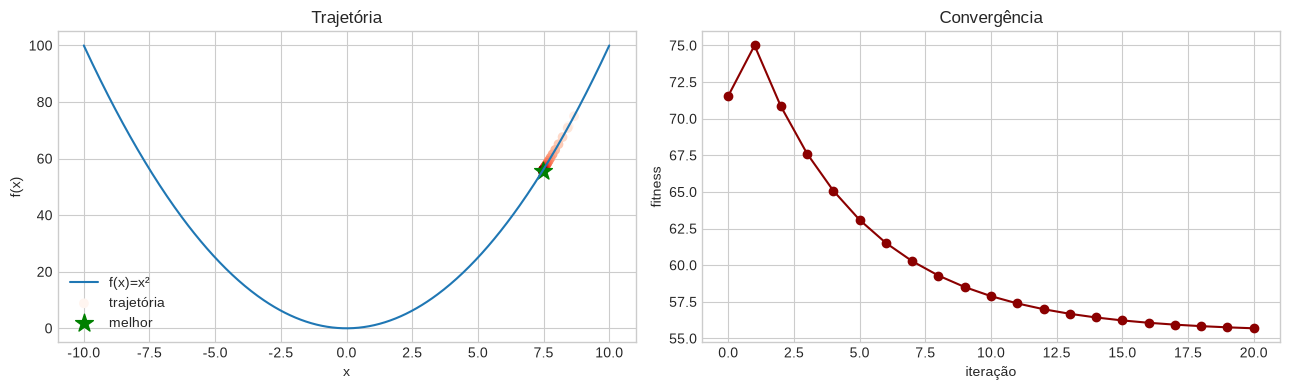

In [2]:
rng = np.random.default_rng(20260902)
ITERACOES, W, C1, C2, LIMITE = 20, 0.8, 1.5, 1.5, 10

def funcao(x):
    return x**2

posicao = rng.uniform(-LIMITE, LIMITE)
velocidade = rng.uniform(-1, 1)
fitness_atual = funcao(posicao)
pBest_pos, pBest_fit = posicao, fitness_atual
gBest_pos, gBest_fit = posicao, fitness_atual
historico_pos, historico_fit = [posicao], [fitness_atual]

print(f"Posição inicial: {posicao:.6f} | fitness inicial: {fitness_atual:.6f}")
for i in range(ITERACOES):
    r1, r2 = rng.random(), rng.random()
    velocidade = (W * velocidade + C1 * r1 * (pBest_pos - posicao) +
                  C2 * r2 * (gBest_pos - posicao))
    posicao = float(np.clip(posicao + velocidade, -LIMITE, LIMITE))
    fitness_atual = funcao(posicao)
    if fitness_atual < pBest_fit:
        pBest_fit, pBest_pos = fitness_atual, posicao
    if fitness_atual < gBest_fit:
        gBest_fit, gBest_pos = fitness_atual, posicao
    historico_pos.append(posicao); historico_fit.append(fitness_atual)
    print(f"Iteração {i+1:2d}: pos = {posicao: .6f}, fitness = {fitness_atual:.8f}")

print(f"\nResultado: melhor posição = {gBest_pos:.8f}; melhor fitness = {gBest_fit:.10f}; erro = {abs(gBest_pos):.8f}")
fig, ax = plt.subplots(1, 2, figsize=(13, 4))
x = np.linspace(-LIMITE, LIMITE, 500)
ax[0].plot(x, funcao(x), label='f(x)=x²')
ax[0].scatter(historico_pos, [funcao(p) for p in historico_pos], c=np.arange(len(historico_pos)), cmap='Reds', label='trajetória')
ax[0].scatter([gBest_pos], [gBest_fit], marker='*', s=180, c='green', label='melhor')
ax[0].set(xlabel='x', ylabel='f(x)', title='Trajetória'); ax[0].legend()
ax[1].plot(historico_fit, 'o-', color='darkred'); ax[1].set(xlabel='iteração', ylabel='fitness', title='Convergência')
plt.tight_layout(); plt.show()

## Missão 2 — O enxame em Rosenbrock

Objetivo: minimizar $f(x,y)=(1-x)^2+100(y-x^2)^2$, cujo ótimo global é $(1,1)$, com valor zero.

Melhor posição: [1.0055 1.0104]; fitness: 0.0000618403; distância até (1,1): 0.011768


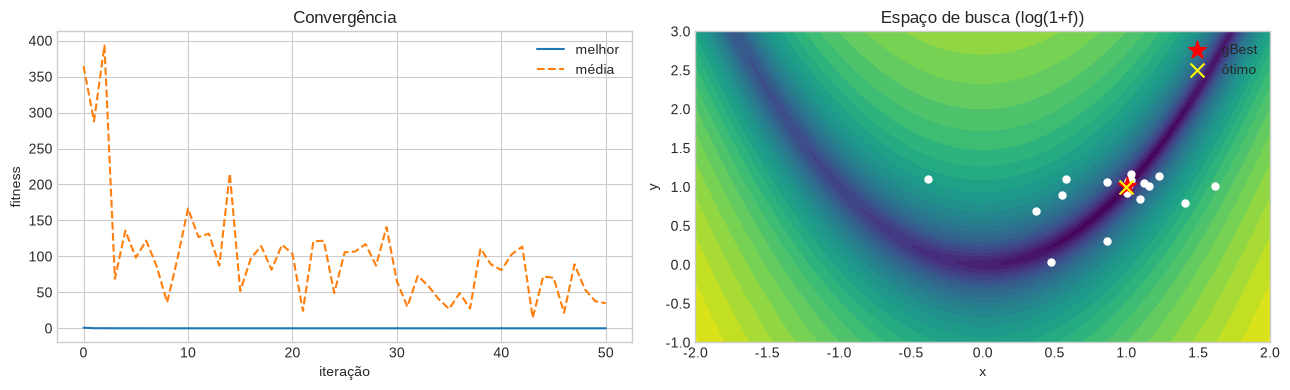

In [3]:
N_PARTICULAS, ITERACOES = 20, 50
W, C1, C2 = 0.7, 1.8, 1.8
X_MIN, X_MAX, Y_MIN, Y_MAX = -2, 2, -1, 3
rng = np.random.default_rng(20260903)

def rosenbrock(posicao):
    x, y = posicao
    return (1-x)**2 + 100*(y-x**2)**2

def criar_particula_rosen():
    pos = rng.uniform([X_MIN, Y_MIN], [X_MAX, Y_MAX])
    vel = rng.uniform(-0.5, 0.5, 2)
    fit = rosenbrock(pos)
    return {'posicao': pos, 'velocidade': vel, 'fitness': fit, 'pBest_pos': pos.copy(), 'pBest_fit': fit}

def atualizar_velocidade_rosen(p, gbest):
    r1, r2 = rng.random(2), rng.random(2)
    return W*p['velocidade'] + C1*r1*(p['pBest_pos']-p['posicao']) + C2*r2*(gbest-p['posicao'])

def atualizar_posicao_rosen(p):
    return np.clip(p['posicao'] + p['velocidade'], [X_MIN, Y_MIN], [X_MAX, Y_MAX])

enxame = [criar_particula_rosen() for _ in range(N_PARTICULAS)]
melhor = min(enxame, key=lambda p: p['fitness'])
gbest, gfit = melhor['posicao'].copy(), melhor['fitness']
hist_melhor, hist_media = [gfit], [np.mean([p['fitness'] for p in enxame])]
for it in range(ITERACOES):
    for p in enxame:
        p['velocidade'] = atualizar_velocidade_rosen(p, gbest)
        p['posicao'] = atualizar_posicao_rosen(p)
        p['fitness'] = rosenbrock(p['posicao'])
        if p['fitness'] < p['pBest_fit']:
            p['pBest_fit'], p['pBest_pos'] = p['fitness'], p['posicao'].copy()
        if p['fitness'] < gfit:
            gfit, gbest = p['fitness'], p['posicao'].copy()
    hist_melhor.append(gfit); hist_media.append(np.mean([p['fitness'] for p in enxame]))
print(f"Melhor posição: {gbest}; fitness: {gfit:.10f}; distância até (1,1): {np.linalg.norm(gbest-[1,1]):.6f}")
fig, ax = plt.subplots(1, 2, figsize=(13,4))
ax[0].plot(hist_melhor, label='melhor'); ax[0].plot(hist_media, '--', label='média'); ax[0].set(title='Convergência', xlabel='iteração', ylabel='fitness'); ax[0].legend()
xx, yy = np.meshgrid(np.linspace(X_MIN,X_MAX,150), np.linspace(Y_MIN,Y_MAX,150))
zz = (1-xx)**2 + 100*(yy-xx**2)**2
ax[1].contourf(xx, yy, np.log1p(zz), levels=30, cmap='viridis')
ax[1].scatter([p['posicao'][0] for p in enxame], [p['posicao'][1] for p in enxame], c='white', s=25)
ax[1].scatter(*gbest, c='red', marker='*', s=180, label='gBest'); ax[1].scatter(1,1,c='yellow',marker='x',s=100,label='ótimo')
ax[1].set(title='Espaço de busca (log(1+f))', xlabel='x', ylabel='y'); ax[1].legend()
plt.tight_layout(); plt.show()

## Missão 3 — Otimização logística

São 50 clientes, 5 centros e demanda individual. Cada cliente é atendido pelo centro mais próximo; o custo é `distância × demanda`. O fitness é o custo positivo; como o objetivo é minimização, o melhor valor é o menor custo.

Custo inicial: 4159.95
Custo final: 3445.44 | melhoria: 17.18%
Centro 1: (1.627, 5.100)
Centro 2: (6.460, 4.100)
Centro 3: (7.521, 7.695)
Centro 4: (7.783, 1.938)
Centro 5: (3.915, 1.239)


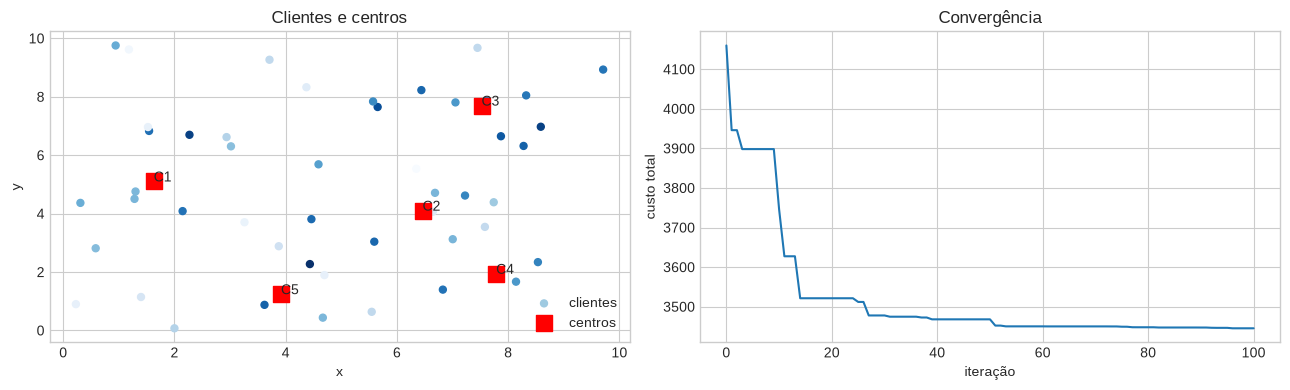

In [4]:
NUM_CLIENTES, NUM_CENTROS, NUM_PARTICULAS, ITERACOES, LIMITE = 50, 5, 30, 100, 10
W, C1, C2 = 0.7, 1.8, 1.8
rng = np.random.default_rng(42)
clientes = rng.random((NUM_CLIENTES, 2)) * LIMITE
demandas = rng.integers(1, 100, NUM_CLIENTES)

def fitness_logistica(posicoes_centros):
    centros = np.asarray(posicoes_centros).reshape(NUM_CENTROS, 2)
    distancias = np.linalg.norm(clientes[:, None, :] - centros[None, :, :], axis=2)
    return float(np.sum(np.min(distancias, axis=1) * demandas))

def criar_particula_logistica():
    pos = rng.uniform(0, LIMITE, NUM_CENTROS*2); vel = rng.uniform(-0.5,0.5,NUM_CENTROS*2)
    fit = fitness_logistica(pos)
    return {'posicao':pos, 'velocidade':vel, 'fitness':fit, 'pBest_pos':pos.copy(), 'pBest_fit':fit}

def atualizar_velocidade_logistica(p, gbest):
    r1, r2 = rng.random(NUM_CENTROS*2), rng.random(NUM_CENTROS*2)
    return W*p['velocidade'] + C1*r1*(p['pBest_pos']-p['posicao']) + C2*r2*(gbest-p['posicao'])

def atualizar_posicao_logistica(p):
    return np.clip(p['posicao'] + p['velocidade'], 0, LIMITE)

# custo inicial de referência e PSO
enxame = [criar_particula_logistica() for _ in range(NUM_PARTICULAS)]
custo_inicial = min(p['fitness'] for p in enxame)
melhor = min(enxame, key=lambda p:p['fitness']); gbest, gfit = melhor['posicao'].copy(), melhor['fitness']
hist = [gfit]
for it in range(ITERACOES):
    for p in enxame:
        p['velocidade'] = atualizar_velocidade_logistica(p, gbest)
        p['posicao'] = atualizar_posicao_logistica(p); p['fitness'] = fitness_logistica(p['posicao'])
        if p['fitness'] < p['pBest_fit']: p['pBest_fit'], p['pBest_pos'] = p['fitness'], p['posicao'].copy()
        if p['fitness'] < gfit: gfit, gbest = p['fitness'], p['posicao'].copy()
    hist.append(gfit)
centros = gbest.reshape(NUM_CENTROS,2)
print(f"Custo inicial: {custo_inicial:.2f}")
print(f"Custo final: {gfit:.2f} | melhoria: {(1-gfit/custo_inicial)*100:.2f}%")
for i,c in enumerate(centros,1): print(f"Centro {i}: ({c[0]:.3f}, {c[1]:.3f})")
fig, ax = plt.subplots(1,2,figsize=(13,4))
ax[0].scatter(clientes[:,0], clientes[:,1], c=demandas, cmap='Blues', s=25, label='clientes')
ax[0].scatter(centros[:,0], centros[:,1], c='red', marker='s', s=120, label='centros')
for i,c in enumerate(centros,1): ax[0].annotate(f'C{i}',c)
ax[0].set(title='Clientes e centros', xlabel='x', ylabel='y'); ax[0].legend()
ax[1].plot(hist); ax[1].set(title='Convergência', xlabel='iteração', ylabel='custo total')
plt.tight_layout(); plt.show()

## Missão 4 — Otimização de parâmetros

Cada configuração é executada cinco vezes no mesmo problema, com sementes diferentes. A comparação usa custo médio, desvio-padrão, melhor e pior custo.

| Experimento | Custo médio | Desvio-padrão | Melhor | Pior |
|---|---:|---:|---:|---:|
| Padrão | 3374.33 | 79.06 | 3290.20 | 3524.28 |
| Inércia Alta | 3773.33 | 191.67 | 3447.09 | 4036.77 |
| Inércia Baixa | 3234.97 | 3.74 | 3232.02 | 3242.28 |
| Cognitivo Alto | 3552.64 | 122.46 | 3427.57 | 3707.55 |
| Social Alto | 3695.95 | 35.87 | 3628.58 | 3733.42 |
| Mais Partículas | 3370.72 | 116.32 | 3254.61 | 3572.43 |

Melhor média: Inércia Baixa | Pior média: Inércia Alta


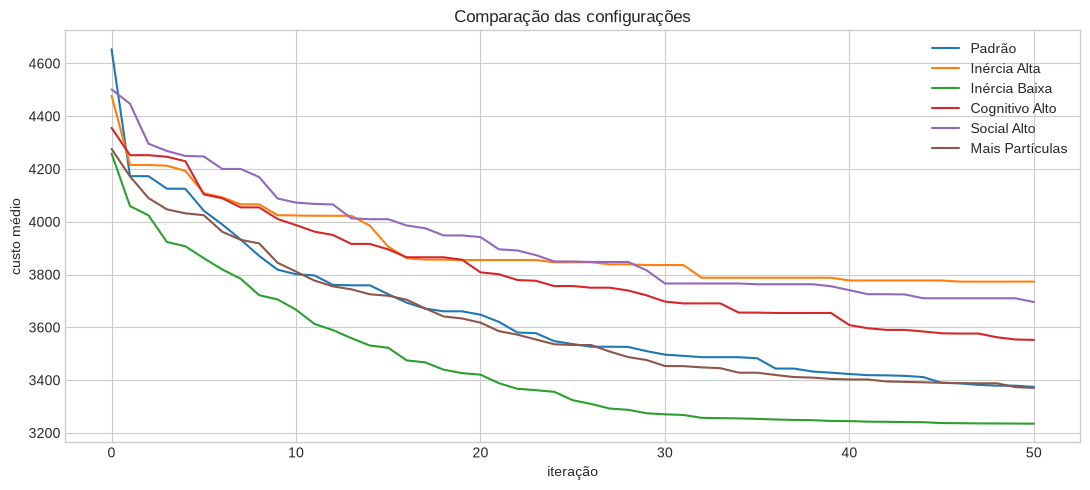

In [5]:
BASE = {'num_particulas':30,'iteracoes':50,'w':0.7,'c1':1.8,'c2':1.8,'limite':10,'num_centros':5}
EXPERIMENTOS = [
 ('Padrão', BASE.copy()), ('Inércia Alta', {**BASE,'w':0.9}), ('Inércia Baixa',{**BASE,'w':0.5}),
 ('Cognitivo Alto',{**BASE,'c1':2.5}), ('Social Alto',{**BASE,'c2':2.5}), ('Mais Partículas',{**BASE,'num_particulas':60})]
rng_data = np.random.default_rng(42)
clientes_exp = rng_data.random((50,2))*10; demandas_exp = rng_data.integers(1,100,50)

def rodar(params, seed):
    r = np.random.default_rng(seed); dim=10; nc=params['num_centros']
    def fit(pos):
        centros=pos.reshape(nc,2); d=np.linalg.norm(clientes_exp[:,None,:]-centros[None,:,:],axis=2)
        return float(np.sum(np.min(d,axis=1)*demandas_exp))
    swarm=[]
    for _ in range(params['num_particulas']):
        pos=r.uniform(0,params['limite'],dim); vel=r.uniform(-.5,.5,dim); f=fit(pos)
        swarm.append({'pos':pos,'vel':vel,'fit':f,'pb':pos.copy(),'pf':f})
    best=min(swarm,key=lambda p:p['fit']); gb=best['pos'].copy(); gf=best['fit']; hist=[gf]
    for _ in range(params['iteracoes']):
        for p in swarm:
            r1,r2=r.random(dim),r.random(dim)
            p['vel']=params['w']*p['vel']+params['c1']*r1*(p['pb']-p['pos'])+params['c2']*r2*(gb-p['pos'])
            p['pos']=np.clip(p['pos']+p['vel'],0,params['limite']); p['fit']=fit(p['pos'])
            if p['fit']<p['pf']: p['pf'],p['pb']=p['fit'],p['pos'].copy()
            if p['fit']<gf: gf,gb=p['fit'],p['pos'].copy()
        hist.append(gf)
    return gf, hist

resultados={}
for idx,(nome,p) in enumerate(EXPERIMENTOS):
    runs=[rodar(p, 1000+idx*100+i) for i in range(5)]
    custos=[x[0] for x in runs]
    resultados[nome]={'custo_medio':np.mean(custos),'std':np.std(custos),'melhor':min(custos),'pior':max(custos),'historico':np.mean([x[1] for x in runs],axis=0),'params':p}

print('| Experimento | Custo médio | Desvio-padrão | Melhor | Pior |')
print('|---|---:|---:|---:|---:|')
for nome,d in resultados.items(): print(f"| {nome} | {d['custo_medio']:.2f} | {d['std']:.2f} | {d['melhor']:.2f} | {d['pior']:.2f} |")
melhor_nome=min(resultados,key=lambda n:resultados[n]['custo_medio']); pior_nome=max(resultados,key=lambda n:resultados[n]['custo_medio'])
print(f"\nMelhor média: {melhor_nome} | Pior média: {pior_nome}")
plt.figure(figsize=(11,5))
for nome,d in resultados.items(): plt.plot(d['historico'],label=nome)
plt.xlabel('iteração'); plt.ylabel('custo médio'); plt.title('Comparação das configurações'); plt.legend(); plt.tight_layout(); plt.show()

## Relatório final

**1. O que é PSO?** PSO é uma meta-heurística de inteligência coletiva em que partículas representam soluções candidatas. A cada iteração, cada partícula combina sua velocidade anterior (inércia), sua melhor posição histórica (componente cognitivo) e a melhor posição conhecida pelo enxame (componente social). Depois, a posição é atualizada e avaliada novamente.

**2. pBest e gBest.** `pBest` é a melhor solução encontrada individualmente por uma partícula; `gBest` é a melhor solução encontrada por todo o enxame. O primeiro preserva exploração baseada na experiência local, enquanto o segundo coordena a convergência coletiva.

**3. Síntese das missões.** A partícula solitária consegue reduzir o erro para o mínimo de $x^2$, mas depende fortemente da trajetória aleatória inicial. O enxame explora várias regiões simultaneamente e encontra uma solução próxima do mínimo de Rosenbrock. Na logística, o custo final é menor que o custo inicial, mantendo cinco centros e associando cada cliente ao centro mais próximo.

**4. Parâmetros.** A melhor e a pior configuração, além dos valores numéricos, estão na tabela gerada acima. Em geral, aumentar a inércia favorece exploração, mas pode retardar a estabilização; inércia baixa favorece refinamento local, mas pode causar convergência prematura. Valores maiores de `c1` tornam as partículas mais individualistas, enquanto valores maiores de `c2` aumentam a influência social. Mais partículas ampliam a diversidade e tendem a melhorar a robustez, ao custo de maior tempo de execução.

**Dificuldades e impressão.** A principal dificuldade foi manter a convenção de minimização consistente: o fitness usado aqui é o custo positivo, portanto o melhor fitness é o menor valor numérico. A atividade mostrou como a memória individual e a cooperação do enxame transformam regras simples de movimento em uma solução útil para um problema logístico.